We will use Depthwise Separable Convolution: 
- one 3×3 filter per input channel, so 128 separate 3×3 filters — learning where
- hen a pointwise 1×1 conv (learning how to mix channels)

We will build the same network we built is normal CNN : CNNv01 class, but use Depthwise layers.

Param calculation: 
- Standard conv: K × K × Cin × Cout = 3 x 3 × 128 × 256 = 294,912 parameters
- Depthwise separable: (K × K × Cin) + (1 × 1 × Cin × Cout) = (9 × 128) + (128 × 256) = 1,152 + 32,768 = 33,920 parameters — roughly an 88% reduction.

In [2]:
import polars as pl
import numpy as np

import matplotlib.pyplot as plt
import yaml
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.model_selection import train_test_split


import src.data.utils as dutils
from src.models.neural import DSCNNv01

In [3]:
PATH = "../data/raw/cifar-10-python.tar/cifar-10-python/cifar-10-batches-py/"
comb_df, test_df = dutils.read_data_v2(PATH)

with open("../configs/base_config.yaml", 'r') as f:
    base_config = yaml.safe_load(f)

comb_df.shape, test_df.shape

C:\Work\Project\cv-architecture-sprint-cifar\src\data\utils.py:10: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(fo, encoding='bytes')


((50000, 3), (10000, 3))

In [4]:
torch.manual_seed(base_config["base"]["random_state"])
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
X = comb_df["data"]; y = comb_df["label"]
X_test = test_df["data"]; y_test = test_df["label"]
X_train, X_val, y_train, y_val = train_test_split(X, y, 
                                                  test_size=base_config["base"]["val_split"], 
                                                  random_state=base_config["base"]["random_state"], 
                                                  stratify=y)


print("Train size: ", X_train.shape, y_train.shape)
print("Test size: ", X_test.shape, y_test.shape)
print("Val size: ", X_val.shape, y_val.shape)

Train size:  (40000,) (40000,)
Test size:  (10000,) (10000,)
Val size:  (10000,) (10000,)


In [6]:
train_df = pl.DataFrame({"data": X_train, "label": y_train})
val_df = pl.DataFrame({"data": X_val, "label": y_val})

train_df.shape, val_df.shape

((40000, 2), (10000, 2))

In [7]:
train_dataset = dutils.CIFARData(train_df)
test_dataset = dutils.CIFARData(test_df)
val_dataset = dutils.CIFARData(val_df)

train_loader = DataLoader(train_dataset, 
                         batch_size=base_config["neural"]["train_batch_size"], shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, 
                       batch_size=base_config["neural"]["batch_size"], num_workers=2)
test_loader = DataLoader(test_dataset, 
                        batch_size=base_config["neural"]["batch_size"], num_workers=2)

In [8]:
from torchvision import transforms

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

val_tf = transforms.Compose([
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

In [11]:
import os

meta = os.path.join(PATH, "batches.meta")

metadata = dutils.read_pkl(meta)
label_name = [l.decode("utf-8") for l in metadata[b'label_names']]

In [ ]:
net = DSCNNv01(
    input_ch= 3,
    n_classes=len(y.unique())
).to(base_config["base"]["gpu"])
optim = torch.optim.AdamW(net.parameters(), lr=1e-3, 
                          weight_decay=1e-2)
criterion = nn.CrossEntropyLoss()

In [13]:
from sklearn.metrics import accuracy_score
from tqdm import tqdm
def train(model: nn.Module,train_loader: DataLoader, 
          val_loader: DataLoader, epoch: int, 
          label_name: list[str], optimizer, criterion, scheduler = None):
    
    history = {
        "train_loss": [],
        "val_loss": [],
        "accuracy_score": []
    }
    
    for epoch in  tqdm(range(1,epoch + 1), total=epoch):
        y_val_pred = []
        y_val = []
        
        train_loss = 0.0
        
        model.train()
        for step, batch in enumerate(train_loader, 1):
            optimizer.zero_grad()
            
            _data = batch["data"]
            _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
            
            _data = _data.reshape((_data.shape[0], 3, 32, 32))
            _data = _data / 255.0
            _data = train_tf(_data)
            _data = _data.to(base_config["base"]["gpu"])
            
            
            logit = model(_data)
            loss = criterion(logit, _label)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss
        train_loss = train_loss / len(train_loader)
        print(f"Training loss on epoch: {epoch}: {train_loss}")
        if scheduler:
            scheduler.step()
        
        val_loss = 0.0
        model.eval()
        with torch.no_grad():
            for step, batch in enumerate(val_loader, 1):
                _data = batch["data"]
                _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
                
                _data = _data.reshape((_data.shape[0], 3, 32, 32))
                _data = _data / 255.0
                _data = val_tf(_data)
                
                _data = _data.to(base_config["base"]["gpu"])
                
                logit = model(_data)
                loss = criterion(logit, _label)
                
                val_loss += loss
                y_pred = logit.argmax(1)
                
                y_val.extend(_label.cpu().numpy())
                y_val_pred.extend(y_pred.cpu().numpy())
        val_loss = val_loss / len(val_loader)
        print(f"Val loss on epoch: {epoch}: {val_loss}")
        
        f = accuracy_score(y_val, y_val_pred)
        print(f"Val accuracy_score on epoch: {epoch}: {f}")
        
        history["train_loss"].append(train_loss.detach().cpu().numpy())
        history["val_loss"].append(val_loss.detach().cpu().numpy())
        history["accuracy_score"].append(f)

    return history

In [14]:
h1 = train(
    model = net,train_loader = train_loader, 
    val_loader = val_loader, epoch = 10, 
    label_name = label_name, optimizer = optim, 
    criterion = criterion, scheduler = None
)

  0%|          | 0/10 [00:00<?, ?it/s]

Training loss on epoch: 1: 1.9367175102233887


 10%|█         | 1/10 [00:18<02:48, 18.74s/it]

Val loss on epoch: 1: 1.7115087509155273
Val accuracy_score on epoch: 1: 0.3825
Training loss on epoch: 2: 1.7503917217254639


 20%|██        | 2/10 [00:37<02:28, 18.52s/it]

...

Val loss on epoch: 8: 1.4347611665725708
Val accuracy_score on epoch: 8: 0.4842
Training loss on epoch: 9: 1.5736360549926758


 90%|█████████ | 9/10 [02:40<00:17, 17.64s/it]

Val loss on epoch: 9: 1.3954765796661377
Val accuracy_score on epoch: 9: 0.5039
Training loss on epoch: 10: 1.5596051216125488


100%|██████████| 10/10 [02:59<00:00, 17.94s/it]

Val loss on epoch: 10: 1.4059687852859497
Val accuracy_score on epoch: 10: 0.4996


In [ ]:
net2 = DSCNNv01(
    input_ch= 3,
    n_classes=len(y.unique())
).to(base_config["base"]["gpu"])
optim = torch.optim.AdamW(net2.parameters(), lr=1e-3, 
                          weight_decay=1e-2)
criterion = nn.CrossEntropyLoss()

In [16]:
h2 = train(
    model = net2, train_loader = train_loader, 
    val_loader = val_loader, epoch = 30, 
    label_name = label_name, optimizer = optim, 
    criterion = criterion, scheduler = None
)

  0%|          | 0/30 [00:00<?, ?it/s]

Training loss on epoch: 1: 1.9427169561386108


  3%|▎         | 1/30 [00:18<09:06, 18.85s/it]

Val loss on epoch: 1: 1.7399951219558716
Val accuracy_score on epoch: 1: 0.3914
Training loss on epoch: 2: 1.7510446310043335


  7%|▋         | 2/30 [00:36<08:31, 18.26s/it]

...

Val loss on epoch: 28: 1.3450407981872559
Val accuracy_score on epoch: 28: 0.5238
Training loss on epoch: 29: 1.4984904527664185


 97%|█████████▋| 29/30 [08:41<00:17, 17.52s/it]

Val loss on epoch: 29: 1.3356226682662964
Val accuracy_score on epoch: 29: 0.5263
Training loss on epoch: 30: 1.4948471784591675


100%|██████████| 30/30 [08:59<00:00, 17.98s/it]

Val loss on epoch: 30: 1.3152852058410645
Val accuracy_score on epoch: 30: 0.5326


In [17]:
import matplotlib.pyplot as plt

def plot_neural(epochs: int, train_loss: list, val_loss: list):

    plt.plot(
        range(epochs), train_loss, label='Training Loss', linewidth=2.0, color='blue', ls='dashed'
    )
    plt.plot(
        range(epochs), val_loss, label='Val Loss', linewidth=2.0, color='green', ls='solid'
    )
    plt.plot(
        range(epochs), [min(val_loss)]*epochs, label='Min Val Loss', linewidth=0.8, color='black', ls='dotted'
    )
    plt.legend()
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(axis='x')

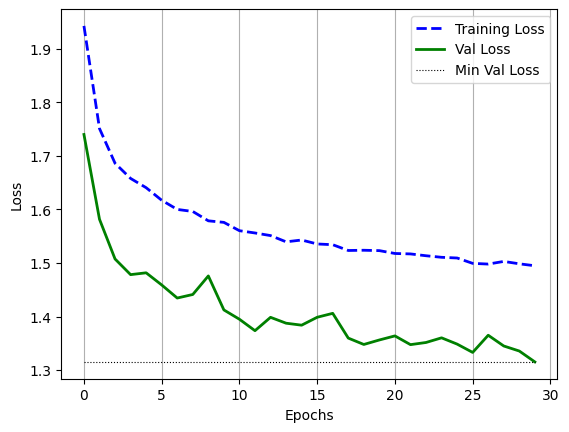

In [18]:
train_loss = h2["train_loss"]
val_loss = h2["val_loss"]
plot_neural(
    epochs= len(train_loss), train_loss= train_loss, val_loss = val_loss
)

In [20]:
from src.eval.metrics import format_cm, evaluate

In [22]:
y_test_v = []
y_test_pred = []

net.eval()
with torch.no_grad():
    for step, batch in enumerate(test_loader, 1):
        _data = batch["data"]
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        
        _data = _data.reshape((_data.shape[0], 3, 32, 32))
        _data = _data / 255.0
        _data = val_tf(_data)
        _data = _data.to(base_config["base"]["gpu"])
        
        logit = net(_data)
        y_pred = logit.argmax(1)
        
        y_test_v.extend(_label.cpu().numpy())
        y_test_pred.extend(y_pred.cpu().numpy())

cm = evaluate(y_test_v, y_test_pred)
format_cm(cm, class_names=label_name, normalize=True)

              precision    recall  f1-score   support

           0     0.5610    0.5380    0.5493      1000
           1     0.5592    0.6520    0.6020      1000
           2     0.4619    0.3580    0.4034      1000
           3     0.3718    0.3290    0.3491      1000
           4     0.5441    0.3270    0.4085      1000
           5     0.4915    0.3480    0.4075      1000
           6     0.4822    0.6790    0.5640      1000
           7     0.4978    0.5580    0.5262      1000
           8     0.5805    0.6490    0.6128      1000
           9     0.4496    0.5660    0.5011      1000

    accuracy                         0.5004     10000
   macro avg     0.5000    0.5004    0.4924     10000
weighted avg     0.5000    0.5004    0.4924     10000



,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
True: airplane,0.538,0.062,0.043,0.022,0.012,0.002,0.035,0.023,0.176,0.087
True: automobile,0.028,0.652,0.008,0.013,0.004,0.010,0.016,0.020,0.091,0.158
True: bird,0.087,0.029,0.358,0.080,0.092,0.054,0.142,0.101,0.018,0.039
True: cat,0.053,0.027,0.064,0.329,0.023,0.158,0.178,0.063,0.024,0.081
True: deer,0.056,0.015,0.113,0.057,0.327,0.020,0.167,0.172,0.037,0.036
True: dog,0.025,0.022,0.074,0.216,0.024,0.348,0.107,0.109,0.026,0.049
True: frog,0.005,0.013,0.062,0.064,0.068,0.022,0.679,0.042,0.011,0.034
True: horse,0.042,0.031,0.034,0.074,0.032,0.062,0.043,0.558,0.015,0.109
True: ship,0.092,0.074,0.008,0.016,0.015,0.022,0.013,0.011,0.649,0.100
True: truck,0.033,0.241,0.011,0.014,0.004,0.010,0.028,0.022,0.071,0.566


In [21]:
y_test_v2 = []
y_test_pred2 = []

net2.eval()
with torch.no_grad():
    for step, batch in enumerate(test_loader, 1):
        _data = batch["data"]
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        
        _data = _data.reshape((_data.shape[0], 3, 32, 32))
        _data = _data / 255.0
        _data = val_tf(_data)
        _data = _data.to(base_config["base"]["gpu"])
        
        logit = net2(_data)
        y_pred = logit.argmax(1)
        
        y_test_v2.extend(_label.cpu().numpy())
        y_test_pred2.extend(y_pred.cpu().numpy())

cm2 = evaluate(y_test_v2, y_test_pred2)
format_cm(cm2, class_names=label_name, normalize=True)

              precision    recall  f1-score   support

           0     0.5806    0.5690    0.5747      1000
           1     0.6244    0.6200    0.6222      1000
           2     0.4793    0.3940    0.4325      1000
           3     0.3920    0.3230    0.3542      1000
           4     0.5072    0.4580    0.4813      1000
           5     0.5042    0.3560    0.4174      1000
           6     0.5301    0.6860    0.5981      1000
           7     0.5719    0.6320    0.6005      1000
           8     0.5836    0.7050    0.6386      1000
           9     0.5313    0.6190    0.5718      1000

    accuracy                         0.5362     10000
   macro avg     0.5305    0.5362    0.5291     10000
weighted avg     0.5305    0.5362    0.5291     10000



,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
True: airplane,0.569,0.042,0.043,0.017,0.018,0.003,0.033,0.026,0.180,0.069
True: automobile,0.027,0.620,0.011,0.016,0.005,0.008,0.012,0.022,0.083,0.196
True: bird,0.087,0.027,0.394,0.060,0.143,0.062,0.103,0.068,0.027,0.029
True: cat,0.048,0.019,0.082,0.323,0.049,0.156,0.164,0.065,0.030,0.064
True: deer,0.061,0.008,0.097,0.052,0.458,0.020,0.120,0.123,0.045,0.016
True: dog,0.021,0.011,0.084,0.210,0.052,0.356,0.108,0.099,0.030,0.029
True: frog,0.004,0.009,0.055,0.047,0.106,0.029,0.686,0.019,0.020,0.025
True: horse,0.042,0.018,0.036,0.058,0.052,0.054,0.034,0.632,0.024,0.050
True: ship,0.085,0.061,0.007,0.024,0.015,0.011,0.013,0.011,0.705,0.068
True: truck,0.036,0.178,0.013,0.017,0.005,0.007,0.021,0.040,0.064,0.619


In [23]:
test_df_shifted = test_df.with_columns(pl.Series("data",[dutils.shift_data(data_list) for data_list in test_df["data"].to_list()] )) 
test_shifted_dataset = dutils.CIFARData(test_df_shifted)
test_shifted_loader = DataLoader(test_shifted_dataset, 
                       batch_size=base_config["neural"]["batch_size"], num_workers=2)

In [24]:
y_test_v_shifted = []
y_test_pred_shifted = []

net.eval()
with torch.no_grad():
    for step, batch in enumerate(test_shifted_loader, 1):
        _data = batch["data"]
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        
        _data = _data.reshape((_data.shape[0], 3, 32, 32))
        _data = _data / 255.0
        _data = val_tf(_data)
        _data = _data.to(base_config["base"]["gpu"])
        
        logit = net(_data)
        y_pred = logit.argmax(1)
        
        y_test_v_shifted.extend(_label.cpu().numpy())
        y_test_pred_shifted.extend(y_pred.cpu().numpy())

cm_shifted = evaluate(y_test_v_shifted, y_test_pred_shifted)
format_cm(cm_shifted, class_names=label_name, normalize=True)

              precision    recall  f1-score   support

           0     0.6383    0.4430    0.5230      1000
           1     0.5737    0.5880    0.5807      1000
           2     0.4323    0.2650    0.3286      1000
           3     0.3213    0.2860    0.3026      1000
           4     0.4579    0.4080    0.4315      1000
           5     0.3722    0.4560    0.4099      1000
           6     0.4639    0.5720    0.5123      1000
           7     0.5652    0.4810    0.5197      1000
           8     0.5691    0.6420    0.6034      1000
           9     0.4159    0.6030    0.4922      1000

    accuracy                         0.4744     10000
   macro avg     0.4810    0.4744    0.4704     10000
weighted avg     0.4810    0.4744    0.4704     10000



,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
True: airplane,0.443,0.046,0.044,0.030,0.023,0.035,0.020,0.033,0.186,0.140
True: automobile,0.019,0.588,0.014,0.020,0.005,0.025,0.030,0.015,0.075,0.209
True: bird,0.065,0.028,0.265,0.086,0.150,0.127,0.145,0.065,0.021,0.048
True: cat,0.021,0.026,0.056,0.286,0.039,0.275,0.134,0.053,0.034,0.076
True: deer,0.036,0.011,0.074,0.060,0.408,0.067,0.166,0.097,0.038,0.043
True: dog,0.008,0.016,0.058,0.185,0.044,0.456,0.086,0.063,0.027,0.057
True: frog,0.004,0.009,0.054,0.119,0.124,0.054,0.572,0.016,0.016,0.032
True: horse,0.022,0.014,0.026,0.064,0.071,0.125,0.053,0.481,0.021,0.123
True: ship,0.058,0.070,0.012,0.024,0.017,0.040,0.010,0.008,0.642,0.119
True: truck,0.018,0.217,0.010,0.016,0.010,0.021,0.017,0.020,0.068,0.603


In [25]:
y_test_v_shifted2 = []
y_test_pred_shifted2 = []

net2.eval()
with torch.no_grad():
    for step, batch in enumerate(test_shifted_loader, 1):
        _data = batch["data"]
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        
        _data = _data.reshape((_data.shape[0], 3, 32, 32))
        _data = _data / 255.0
        _data = val_tf(_data)
        _data = _data.to(base_config["base"]["gpu"])
        
        logit = net2(_data)
        y_pred = logit.argmax(1)
        
        y_test_v_shifted2.extend(_label.cpu().numpy())
        y_test_pred_shifted2.extend(y_pred.cpu().numpy())

cm_shifted2 = evaluate(y_test_v_shifted2, y_test_pred_shifted2)
format_cm(cm_shifted2, class_names=label_name, normalize=True)

              precision    recall  f1-score   support

           0     0.6820    0.4310    0.5282      1000
           1     0.6159    0.5180    0.5627      1000
           2     0.4095    0.3100    0.3529      1000
           3     0.3092    0.3580    0.3318      1000
           4     0.4527    0.4350    0.4437      1000
           5     0.3318    0.5020    0.3995      1000
           6     0.5303    0.4810    0.5045      1000
           7     0.6745    0.4310    0.5259      1000
           8     0.5339    0.6610    0.5907      1000
           9     0.4682    0.6340    0.5387      1000

    accuracy                         0.4761     10000
   macro avg     0.5008    0.4761    0.4779     10000
weighted avg     0.5008    0.4761    0.4779     10000



,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
True: airplane,0.431,0.039,0.071,0.046,0.024,0.039,0.014,0.013,0.221,0.102
True: automobile,0.015,0.518,0.019,0.034,0.005,0.036,0.019,0.010,0.088,0.256
True: bird,0.050,0.023,0.310,0.108,0.143,0.167,0.096,0.031,0.029,0.043
True: cat,0.021,0.020,0.062,0.358,0.038,0.308,0.082,0.031,0.029,0.051
True: deer,0.026,0.015,0.100,0.076,0.435,0.096,0.126,0.048,0.046,0.032
True: dog,0.005,0.008,0.064,0.229,0.047,0.502,0.050,0.041,0.026,0.028
True: frog,0.005,0.011,0.065,0.151,0.146,0.093,0.481,0.005,0.023,0.020
True: horse,0.019,0.018,0.043,0.083,0.093,0.193,0.023,0.431,0.028,0.069
True: ship,0.047,0.060,0.011,0.041,0.017,0.033,0.004,0.007,0.661,0.119
True: truck,0.013,0.129,0.012,0.032,0.013,0.046,0.012,0.022,0.087,0.634


In [26]:
# no of parameters
total_trainable_param = 0
for param in net.parameters():
    if param.requires_grad:
        total_trainable_param += torch.numel(param)
print("Number to total trainable parameters: ",total_trainable_param)

Number to total trainable parameters:  292136


In [27]:
torch.save(net.state_dict(), "../artifacts/dscnn_model1_v01.pth")
torch.save(net2.state_dict(), "../artifacts/dscnn_model2_v01.pth")